#Свёрточные нейросети

На базе
https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

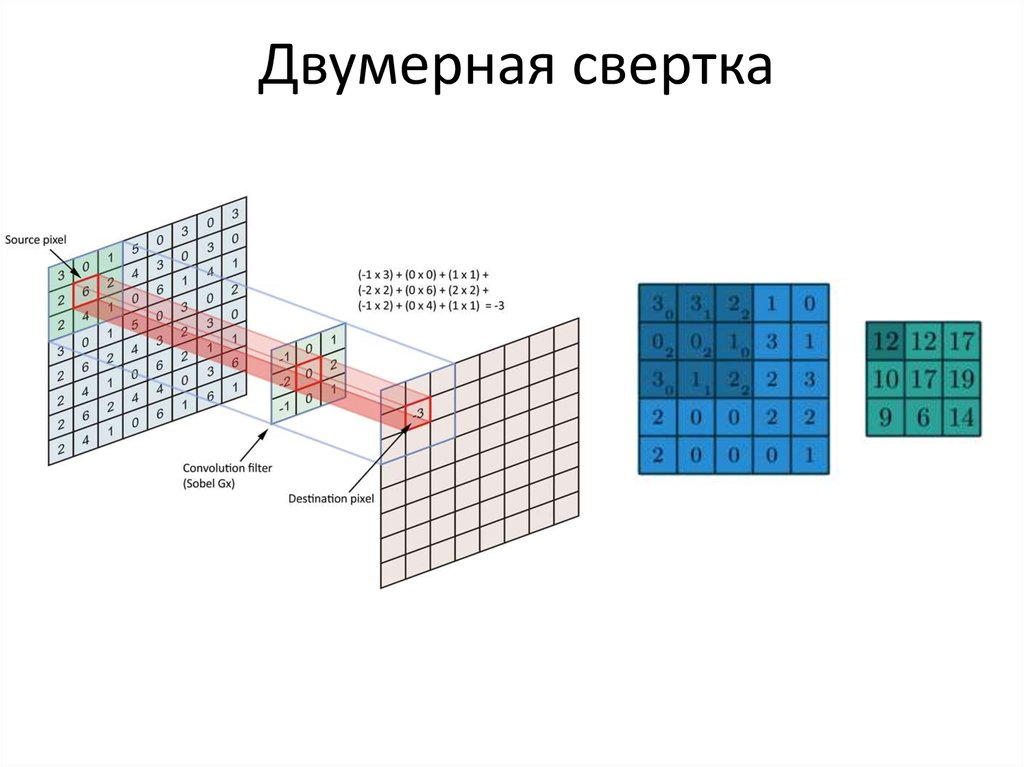

На картинке иделаьно продемонстрирован принцип работы свёрточной нейросети. Она проходит "ядром" размера kernel_size по всей картинке, преобразую и тем саммы находя на ней сложные закономерности

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

После импортирования библиотек, выполним стандартные преобразования - нормализуем картинки и создадим загрузчик данных

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)    #данные для обучения
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)  #данные для тестовой выборки
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:05<00:00, 32.6MB/s]


Давайте просмотрим примеры изображений

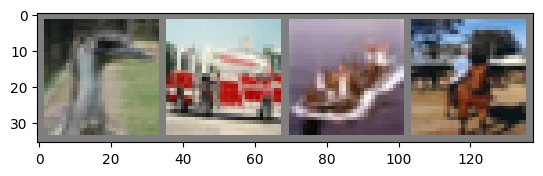

bird  truck ship  horse


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

Conv2d
Применяет двумерную свёртку к входному сигналу, состоящему из нескольких входных плоскостей.
1. in_channels (int) — количество каналов во входном изображении

2. out_channels (int) — количество каналов, получаемых в результате свертки

3. kernel_size (int или кортеж) — размер сверточного ядра

4. stride (int или кортеж, необязательно) — шаг свертки. По умолчанию: 1

5. padding (int, кортеж или str, необязательно) — заполнение, добавляемое ко всем четырем сторонам входных данных. По умолчанию: 0

6. dilation (int или tuple, необязательно) — расстояние между элементами ядра. По умолчанию: 1

7. groups (int, необязательно) — количество заблокированных соединений между входными и выходными каналами. По умолчанию: 1

8. bias (bool, необязательно) — если True, добавляет к выходу обучаемый коэффициент смещения. По умолчанию: True

9. padding_mode (str, необязательно) — 'zeros', 'reflect', 'replicate' или 'circular'. По умолчанию: 'zeros'


В примере ниже мы передаём в Conv2d аргументы (in_channels, out_channels, kernel_size)

In [ ]:
#Создадим структуру нейросети

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

Зададим оптимизатор и функцию потерь

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(3):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.184
[1,  4000] loss: 1.845
[1,  6000] loss: 1.715
[1,  8000] loss: 1.619
[1, 10000] loss: 1.552
[1, 12000] loss: 1.514
[2,  2000] loss: 1.421
[2,  4000] loss: 1.415
[2,  6000] loss: 1.361
[2,  8000] loss: 1.333
[2, 10000] loss: 1.284
[2, 12000] loss: 1.279


KeyboardInterrupt: 

In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')
print(correct, total)

Accuracy of the network on the 10000 test images: 55 %
5525 10000


Accuracy:
1. 63% lr=0.0009 epoches=10